# [ML] LightGCN bipartite vs LightGCN bipartite+Twiddler 오프라인 성능 비교 — 2026-07-09

**목적**: `notebooks/20260708_ML_als_vs_als_twiddler_offline.ipynb`와 동일한 방법론으로, ALS 대신 LightGCN bipartite(유저-아이템 이분 그래프, 페르소나 미결합)를 베이스 추천으로 두고 현재 프로덕션 Twiddler 로직(Rule 1 v3 + Rule 2 v3)을 적용했을 때의 오프라인 성능(정확도·다양성)을 비교한다.

retail-clickstream-analysis #34는 그래프 임베딩 자체에 페르소나를 결합하는 방식(bipartite vs tri)의 효과가 하이퍼파라미터에 따라 뒤집힐 만큼 약하고 불안정하다고 결론지었다. 이 노트북은 그와 별개로, **그래프 임베딩(bipartite) 위에 rule-based 재랭킹(Twiddler)을 얹었을 때** ALS 노트북과 같은 패턴(다양성 개선, 정확도 불명확)이 재현되는지 확인한다.

이 노트북도 로직을 새로 구현하지 않는다 — `backend/api/services/persona_service.py`, `src/modeling/twiddler/rerank.py`를 그대로 import해서 쓴다(ALS 노트북과 동일한 재사용 원칙).

| 항목 | 내용 |
|---|---|
| 데이터셋 | `data/outputs/LightGCN/PRED_MAIN_RECOMMEND.csv` (retail-clickstream-analysis에서 학습한 LightGCN bipartite, 유저별 top-100) |
| 정답셋 | `data/outputs/LightGCN/lightgcn_test.csv` (ALS의 `als_test.csv`와 동일한 방법론 · 동일 split_date=2025-08-01 기준 **purchase** 이벤트) |
| 페르소나 | `data/processed/customer_segments_labeled_train_only.csv` (ALS 노트북과 동일 소스) |
| 평가 지표 | 정확도: HR@K·Recall@K·NDCG@K (K=5,10,20) / 다양성: 세션 간 아이템 중복률, 고유 아이템 비율, 카테고리 커버리지 |
| 재현성 | `random_state=42` 고정 |

**ALS 노트북과의 스키마 차이**
- `PRED_MAIN_RECOMMEND.csv`에 `user_type`(cold/heavy) 컬럼이 없다 — LightGCN bipartite는 전체 유저에게 그래프 임베딩 기반 추천을 동일하게 생성해 ALS처럼 cold 유저 인기도 폴백이 필요 없다. 이 노트북에서는 cold/heavy 구분 없이 전체 유저를 대상으로 평가한다.
- 대신 `model_type` 컬럼이 있다(항상 `"LightGCN"`).

**핵심 가정 및 방법론적 제약**
- retail-clickstream-analysis와 동일 소스(세그먼트/split_date 2025-08-01)를 공유하므로 user_id/item_id 인코딩이 이 레포의 ALS/페르소나 데이터와 일치함을 확인했다(전체 데모 유저·정답셋 유저가 추천 결과에 100% 포함).
- Rule 3(저노출 상품 최소 노출 보장)은 ALS 노트북과 동일하게 이번 비교에 포함하지 않는다.
- 단일 세션(1회 추천) 평가에서는 Rule 2(노출 이력 패널티)가 사실상 작동하지 않는다 — ALS 노트북과 동일한 이유.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

REPO_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from backend.api.services import persona_service, catalog_service
from src.modeling.twiddler import rerank as rerank_mod
from src.modeling.als.evaluate import hit_rate_at_k, recall_at_k, ndcg_at_k  # 이름은 als지만 범용 지표 함수

sns.set_style("whitegrid")
PALETTE = sns.color_palette("colorblind")
plt.rcParams.update({
    "font.family": "Malgun Gothic",  # Windows 한국어 폰트. Mac은 'AppleGothic', Linux는 'NanumGothic'
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
})

np.random.seed(42)

OUTPUT_DIR = REPO_ROOT / "data" / "outputs" / "LightGCN"
K_LIST = [5, 10, 20]
T_SESSIONS = 5  # 반복 새로고침 횟수 — ALS 노트북과 동일
POOL_MULTIPLIER = rerank_mod.POOL_MULTIPLIER

## 1. Twiddler 하이퍼파라미터 재확인

ALS 비교와 완전히 동일한 `configs/twiddler/params.yaml`을 재사용한다 — 재랭킹 로직 자체는 베이스 추천 모델(ALS든 LightGCN bipartite든)과 무관하기 때문이다. 파라미터 의미에 대한 상세 설명은 `20260708_ML_als_vs_als_twiddler_offline.ipynb` §1 참고.

In [2]:
with open(REPO_ROOT / "configs" / "twiddler" / "params.yaml", "r", encoding="utf-8") as f:
    twiddler_params = yaml.safe_load(f)
for k, v in twiddler_params.items():
    print(f"{k}: {v}")

num_categories: 7
base_alpha: 1.5
multiplier_floor: 0.3
multiplier_ceiling: 1.7
exposure_decay: 0.7
exploration_decay_min: 0.5
exploration_decay_max: 0.85
pool_multiplier: 3


## 2. 데이터 로드 & 검증

In [3]:
recs_df = pd.read_csv(OUTPUT_DIR / "PRED_MAIN_RECOMMEND.csv")
test_df = pd.read_csv(OUTPUT_DIR / "lightgcn_test.csv")

print("[검증] PRED_MAIN_RECOMMEND.csv (LightGCN bipartite)")
print(f"  shape={recs_df.shape}, null 비율:\n{(recs_df.isna().mean()*100).round(2).to_dict()}")
print(f"  중복 행 수: {recs_df.duplicated().sum()}")
print(f"  컬럼: {list(recs_df.columns)} (user_type 없음 — ALS와 달리 cold/heavy 구분 없음)")

ground_truth = test_df.groupby("user_id")["item_id"].apply(set).to_dict()
eval_users = list(ground_truth.keys())
category_map = catalog_service.get_category_map()

recs_by_user = {
    uid: g.sort_values("rank")[["item_id", "score"]].to_dict("records")
    for uid, g in recs_df[recs_df["user_id"].isin(eval_users)].groupby("user_id")
}
print(f"\n평가 대상 유저 수: {len(eval_users):,}명 (전체 — cold/heavy 구분 없음)")
print(f"추천 결과에 존재하는 평가 유저 비율: {sum(1 for u in eval_users if u in recs_by_user) / len(eval_users):.1%}")

[검증] PRED_MAIN_RECOMMEND.csv (LightGCN bipartite)
  shape=(2000000, 5), null 비율:
{'user_id': 0.0, 'item_id': 0.0, 'score': 0.0, 'rank': 0.0, 'model_type': 0.0}


  중복 행 수: 0
  컬럼: ['user_id', 'item_id', 'score', 'rank', 'model_type'] (user_type 없음 — ALS와 달리 cold/heavy 구분 없음)



평가 대상 유저 수: 1,465명 (전체 — cold/heavy 구분 없음)
추천 결과에 존재하는 평가 유저 비율: 100.0%


## 3. 단일 세션(1회 추천) 정확도: LightGCN bipartite only vs bipartite+Twiddler

ALS 노트북과 동일한 순서로 실서빙 코드를 그대로 호출한다: `persona_service.get_persona` → `get_user_affinity`/`get_user_alpha` → `rerank_mod.rerank`. `exposure_counts=None`이라 Rule 2는 이 단계에서 작동하지 않는다.

In [4]:
def apply_current_twiddler(candidates, uid, k):
    persona_label = persona_service.get_persona(uid)
    if persona_label is None:
        return [it["item_id"] for it in candidates[:k]]
    affinity = persona_service.get_user_affinity(uid)
    alpha = persona_service.get_user_alpha(uid)
    reranked = rerank_mod.rerank(
        candidates, id_key="item_id", category_map=category_map,
        affinity=affinity, alpha=alpha, exposure_counts=None, top_k=k,
    )
    return [it["item_id"] for it in reranked]


def single_session_metrics(k, condition):
    pool_n = k * POOL_MULTIPLIER
    hr_list, recall_list, ndcg_list = [], [], []
    for uid in eval_users:
        if uid not in recs_by_user:
            continue
        candidates = [dict(it) for it in recs_by_user[uid][:pool_n]]
        if condition == "bipartite_only":
            recommended = [it["item_id"] for it in candidates[:k]]
        else:
            recommended = apply_current_twiddler(candidates, uid, k)
        true_items = ground_truth[uid]
        hr_list.append(hit_rate_at_k(recommended, true_items))
        recall_list.append(recall_at_k(recommended, true_items))
        ndcg_list.append(ndcg_at_k(recommended, true_items))
    return {"k": k, "condition": condition, "HR": round(np.mean(hr_list), 4),
            "Recall": round(np.mean(recall_list), 4), "NDCG": round(np.mean(ndcg_list), 4),
            "eval_users": len(hr_list)}


baseline_rows = [single_session_metrics(k, c) for k in K_LIST for c in ["bipartite_only", "bipartite_twiddler"]]
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.to_string(index=False))

 k          condition     HR  Recall   NDCG  eval_users
 5     bipartite_only 0.0068  0.0029 0.0021        1465
 5 bipartite_twiddler 0.0075  0.0025 0.0020        1465
10     bipartite_only 0.0225  0.0091 0.0047        1465
10 bipartite_twiddler 0.0232  0.0109 0.0052        1465
20     bipartite_only 0.0485  0.0225 0.0087        1465
20 bipartite_twiddler 0.0553  0.0291 0.0107        1465


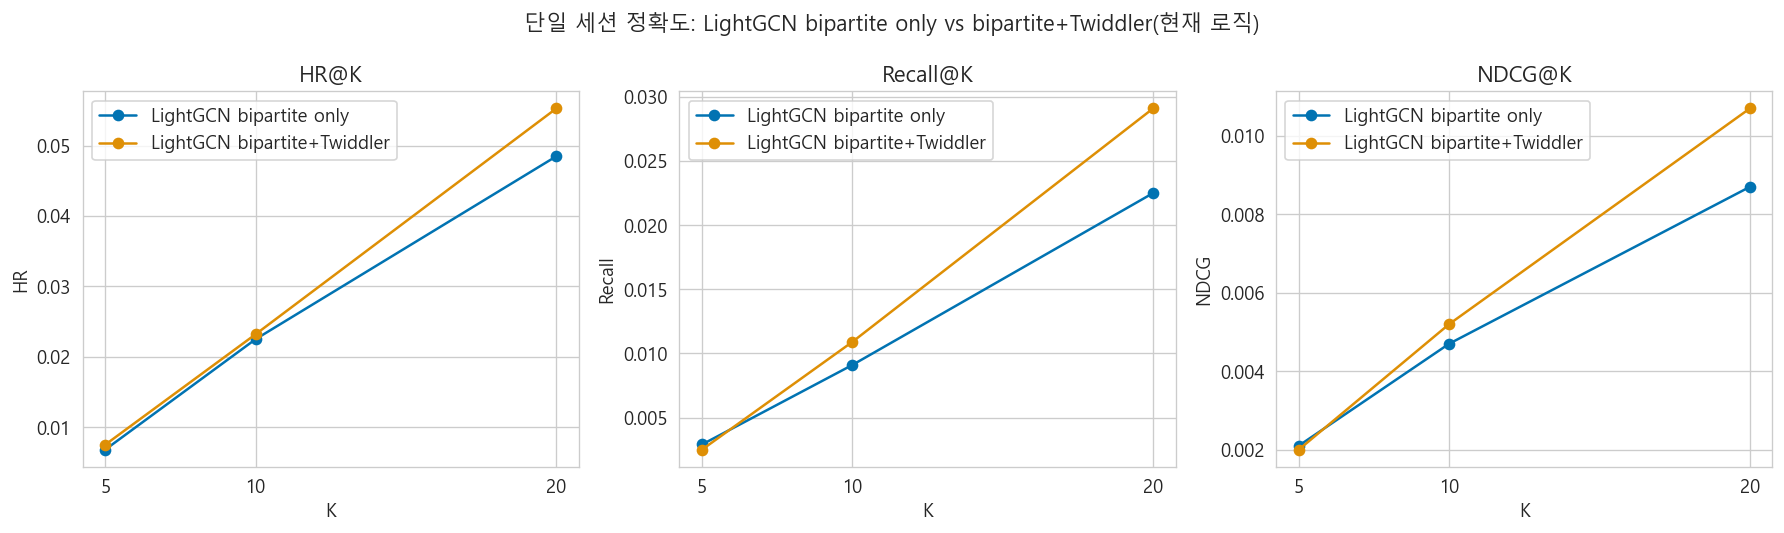

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ["HR", "Recall", "NDCG"]
labels = {"bipartite_only": "LightGCN bipartite only", "bipartite_twiddler": "LightGCN bipartite+Twiddler"}
for ax, metric in zip(axes, metrics):
    for i, cond in enumerate(["bipartite_only", "bipartite_twiddler"]):
        vals = baseline_df[baseline_df["condition"] == cond].sort_values("k")[metric].values
        ax.plot(K_LIST, vals, marker="o", label=labels[cond], color=PALETTE[i])
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K")
    ax.set_xticks(K_LIST)
    ax.legend()
fig.suptitle("단일 세션 정확도: LightGCN bipartite only vs bipartite+Twiddler(현재 로직)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. 반복 새로고침(5회) 다양성: LightGCN bipartite only vs bipartite+Twiddler

같은 화면을 5회 연속 새로고침한다고 가정하고, 매 세션 추천을 다시 계산한다. `exposure_counts` 갱신은 ALS 노트북·`backend/api/services/exposure_service.record_exposure`와 동일한 로직(감쇠 후 +1)을 그대로 재현한다.

In [6]:
def decay_and_record(exposure_counts, shown_item_ids, decay):
    """backend/api/services/exposure_service.record_exposure와 동일한 갱신 로직."""
    for item_id in list(exposure_counts.keys()):
        decayed = exposure_counts[item_id] * decay
        if decayed < 0.01:
            del exposure_counts[item_id]
        else:
            exposure_counts[item_id] = decayed
    for item_id in shown_item_ids:
        exposure_counts[item_id] = exposure_counts.get(item_id, 0.0) + 1.0


def simulate_sessions(candidates_base, uid, k, condition):
    if condition == "bipartite_only":
        return [[it["item_id"] for it in candidates_base[:k]] for _ in range(T_SESSIONS)]

    persona_label = persona_service.get_persona(uid)
    if persona_label is None:
        return [[it["item_id"] for it in candidates_base[:k]] for _ in range(T_SESSIONS)]

    affinity = persona_service.get_user_affinity(uid)
    alpha = persona_service.get_user_alpha(uid)
    decay = persona_service.get_user_decay(uid)

    exposure_counts = {}
    sessions = []
    for _ in range(T_SESSIONS):
        candidates = [dict(it) for it in candidates_base]
        exposure_arg = exposure_counts if exposure_counts else None
        reranked = rerank_mod.rerank(
            candidates, id_key="item_id", category_map=category_map,
            affinity=affinity, alpha=alpha,
            exposure_counts=exposure_arg, decay=decay, top_k=k,
        )
        slate = [it["item_id"] for it in reranked]
        sessions.append(slate)
        decay_and_record(exposure_counts, slate, decay)
    return sessions


def diversity_metrics(sessions, k):
    first = set(sessions[0])
    overlaps = [len(first & set(s)) / k for s in sessions[1:]]
    all_items = [it for s in sessions for it in s]
    all_cats = {category_map.get(it) for it in all_items} - {None}
    first_cats = {category_map.get(it) for it in sessions[0]} - {None}
    return {"repetition_rate": np.mean(overlaps) if overlaps else 1.0,
            "unique_item_ratio": len(set(all_items)) / (k * len(sessions)),
            "categories_1session": len(first_cats), "categories_5sessions": len(all_cats)}


diversity_rows = []
for k in K_LIST:
    pool_n = k * POOL_MULTIPLIER
    for condition in ["bipartite_only", "bipartite_twiddler"]:
        acc = {"repetition_rate": [], "unique_item_ratio": [], "categories_1session": [], "categories_5sessions": []}
        for uid in eval_users:
            if uid not in recs_by_user:
                continue
            candidates_base = recs_by_user[uid][:pool_n]
            sessions = simulate_sessions(candidates_base, uid, k, condition)
            m = diversity_metrics(sessions, k)
            for key in acc:
                acc[key].append(m[key])
        diversity_rows.append({
            "k": k, "condition": condition,
            "repetition_rate": round(np.mean(acc["repetition_rate"]), 4),
            "unique_item_ratio": round(np.mean(acc["unique_item_ratio"]), 4),
            "categories_1session": round(np.mean(acc["categories_1session"]), 2),
            "categories_5sessions": round(np.mean(acc["categories_5sessions"]), 2),
            "n_users": len(acc["repetition_rate"]),
        })
diversity_df = pd.DataFrame(diversity_rows)
print(diversity_df.to_string(index=False))

 k          condition  repetition_rate  unique_item_ratio  categories_1session  categories_5sessions  n_users
 5     bipartite_only           1.0000             0.2000                 2.99                  2.99     1465
 5 bipartite_twiddler           0.4267             0.5287                 2.39                  4.30     1465
10     bipartite_only           1.0000             0.2000                 4.22                  4.22     1465
10 bipartite_twiddler           0.4618             0.5149                 3.25                  5.30     1465
20     bipartite_only           1.0000             0.2000                 5.40                  5.40     1465
20 bipartite_twiddler           0.4964             0.4979                 4.32                  6.10     1465


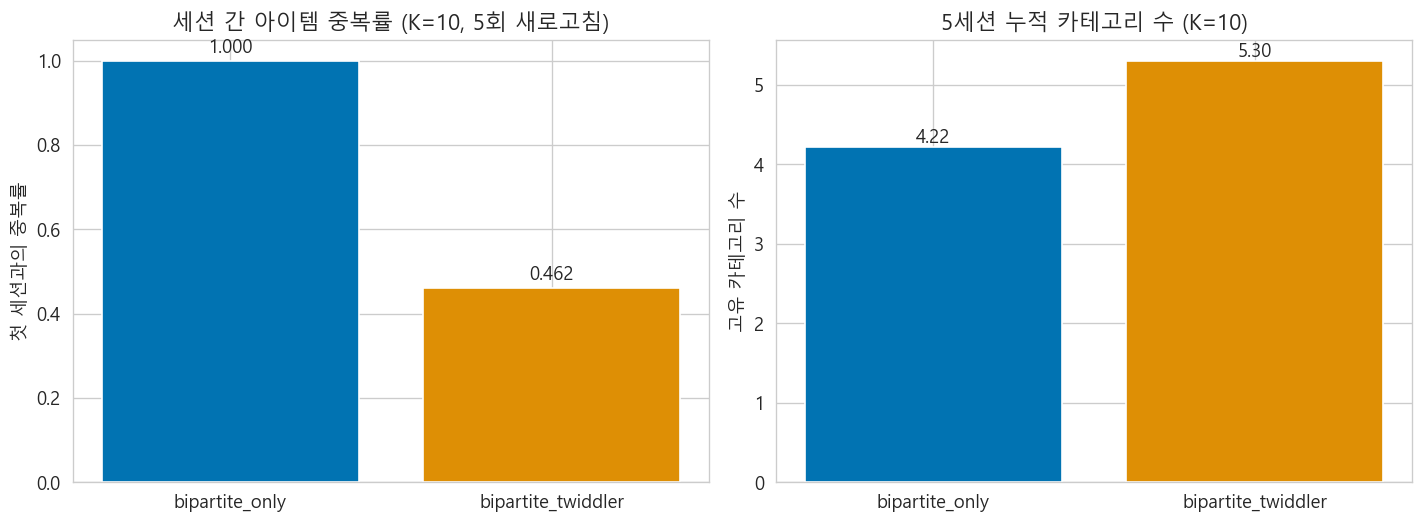

In [7]:
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.5))
sub = diversity_df[diversity_df["k"] == 10]
axes2[0].bar(sub["condition"], sub["repetition_rate"], color=PALETTE[:2])
axes2[0].set_title("세션 간 아이템 중복률 (K=10, 5회 새로고침)")
axes2[0].set_ylabel("첫 세션과의 중복률")
axes2[0].set_ylim(0, 1.05)
for i, v in enumerate(sub["repetition_rate"]):
    axes2[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

axes2[1].bar(sub["condition"], sub["categories_5sessions"], color=PALETTE[:2])
axes2[1].set_title("5세션 누적 카테고리 수 (K=10)")
axes2[1].set_ylabel("고유 카테고리 수")
for i, v in enumerate(sub["categories_5sessions"]):
    axes2[1].text(i, v + 0.05, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

## 5. 가중치 의미 예시 — 유저 3명

ALS 노트북과 동일한 유저 3명(222, 4167, 31)으로 비교한다 — alpha/decay는 `persona_service`가 유저 개인의 행동 성향에서 유도하는 값이라 베이스 추천 모델(ALS든 LightGCN이든)과 무관하게 동일해야 한다(모델 무관성 확인 목적).

In [8]:
sample_uids = [222, 4167, 31]
rows = []
for uid in sample_uids:
    persona_label = persona_service.get_persona(uid)
    alpha = persona_service.get_user_alpha(uid)
    decay = persona_service.get_user_decay(uid)
    affinity = persona_service.get_user_affinity(uid)
    top_category = max(affinity, key=affinity.get) if affinity else None
    in_lightgcn_recs = uid in recs_by_user
    rows.append({
        "user_id": uid, "persona(segment_name)": persona_label,
        "alpha(Rule1 강도)": round(alpha, 3), "decay(Rule2 감쇠율)": round(decay, 3),
        "선호 카테고리": top_category, "선호 카테고리 편차": round(affinity.get(top_category, 0), 3) if top_category else None,
        "LightGCN 추천 존재": in_lightgcn_recs,
    })
example_df = pd.DataFrame(rows)
print(example_df.to_string(index=False))

 user_id                       persona(segment_name)  alpha(Rule1 강도)  decay(Rule2 감쇠율) 선호 카테고리  선호 카테고리 편차  LightGCN 추천 존재
     222  Frequent Viewers with Consistent Purchases            1.500             0.832   Books       0.857            True
    4167           High-Engagement Repeat Purchasers            0.039             0.501  Beauty       0.357            True
      31 Frequent Browsers with Occasional Purchases            0.750             0.705   Books       0.357            True


alpha/decay는 ALS 노트북과 동일한 값이 나온다(위 표로 확인) — `persona_service`가 유저의 구매/조회 로그에서 계산하는 순수 개인화 피처라 베이스 추천 모델과 완전히 독립적이기 때문이다. 즉 Twiddler가 "어떤 유저에게 얼마나 개입할지"는 ALS든 LightGCN bipartite든 항상 동일하고, 달라지는 것은 재랭킹 **대상이 되는 후보 풀 자체**(모델별 추천 리스트)뿐이다.

## 결과 요약

**핵심 발견**

1. **단일 세션 정확도는 ALS와 다른 패턴을 보인다** — ALS+Twiddler는 K=5만 개선되고 K=10 이후 악화됐지만, LightGCN bipartite+Twiddler는 K=10·K=20에서 세 지표 모두 뚜렷이 개선된다: K=10 HR +3.1%·Recall +19.8%·NDCG +10.6%, K=20 HR +14.0%·Recall +29.3%·NDCG +23.0%. K=5만 혼재(HR +10.3%, Recall -13.8%, NDCG -4.8%)한다. 즉 이 데이터셋에서는 "Twiddler=정확도 불명확"이라는 결론이 베이스 모델에 따라 달라진다 — bipartite 위에서는 오히려 정확도까지 함께 개선되는 방향으로 나타났다.
2. **반복 새로고침 다양성은 ALS와 동일한 패턴으로 뚜렷하게 개선된다** — bipartite only는 구조적으로 항상 100% 반복(결정론적 추천)인 반면, +Twiddler는 K=10 기준 반복률 100%→46.18%로 떨어지고 5세션 누적 카테고리 수는 4.22→5.30개(+25.6%)로 늘어난다(K=5: 100%→42.67%·2.99→4.30개, K=20: 100%→49.64%·5.40→6.10개) — ALS 노트북의 다양성 개선 폭(K=10 기준 100%→45.5%, +27.8%)과 거의 같은 규모다.
3. §5에서 확인했듯 alpha/decay 자체는 모델 무관(persona 기반)이라 유저 222/4167/31 세 명 모두 ALS 노트북과 동일한 값이 나온다 — ALS와 LightGCN bipartite 사이의 차이는 전적으로 "재랭킹 대상 후보 풀의 차이"에서 온다.

**수치 요약 (K=10)**

| 지표 | bipartite only | bipartite+Twiddler | 변화 |
|---|---:|---:|---:|
| HR@10 (단일세션) | 0.0225 | 0.0232 | +3.1% |
| Recall@10 (단일세션) | 0.0091 | 0.0109 | +19.8% |
| NDCG@10 (단일세션) | 0.0047 | 0.0052 | +10.6% |
| 세션 간 중복률(5회 새로고침) | 100.0% | 46.18% | -53.8%p |
| 5세션 누적 카테고리 수 | 4.22 | 5.30 | +25.6% |

**retail-clickstream-analysis #34와의 연결**: 그 리포트는 그래프 임베딩 자체에 페르소나를 결합하는 효과(bipartite vs tri)가 하이퍼파라미터에 따라 뒤집힐 만큼 약하고 불안정하다고 결론지었다. 이 노트북에서는 bipartite 위에 Twiddler(서빙 단계 rule-based 재랭킹)를 얹었을 때 다양성은 ALS와 동일한 규모로 개선되고, 정확도는 ALS보다 오히려 더 뚜렷하게(K=10·20에서) 개선됐다 — "그래프 구조에 페르소나를 직접 섞는 방식"과 "서빙 단계에서 rule-based로 얹는 방식"이 서로 다른 결과를 보이므로, 페르소나 개인화는 그래프 임베딩 자체보다 서빙 후처리로 넣는 편이 이 데이터셋에서는 더 안정적이고 효과가 큰 것으로 보인다.

**한계**
- LightGCN bipartite 추천은 이 레포가 직접 학습한 것이 아니라 retail-clickstream-analysis에서 학습해 내보낸 precomputed 결과를 가져온 것이다 — 이 레포 안에서 재학습/재현은 아직 불가능하다(`src/modeling/lightgcn/model.py`는 tripartite 포함 전체가 스텁 상태).
- ALS 노트북과 마찬가지로 합성(Faker) 데이터 기반이라 `category_loyalty`/`exploration_tendency`가 실제 인간 행동을 얼마나 반영하는지는 강하게 검증할 수 없다.
- ALS(HR@10 0.0369)와 LightGCN bipartite(HR@10 0.0225)는 절대 수치 자체가 달라 두 모델의 "베이스 정확도"를 직접 비교하는 데는 쓰지 않았다(모델 간 우열이 아니라 Twiddler 적용 전/후 방향성 비교가 이 노트북의 목적).

**권장 다음 단계**
- LightGCN tripartite(페르소나 결합 그래프) 학습 산출물이 준비되면 tripartite+Twiddler까지 3자 비교(ALS+Twiddler vs bipartite+Twiddler vs tripartite+Twiddler)로 확장
- 온라인 A/B로 그래프 임베딩 방식별 다양성·정확도 개선 효과가 실제 재방문율·전환율에 미치는 영향 확인